# Reduced space and training data
In this notebook we split off some of our precomputed data to use as training data in the OpInf process. We also construct a reduced space. The idea is that none of these decisions (reduced dimension, training parameters, etc.) are done in the other notebooks, but data can just be loaded in. This should steamline the process.

## Imports

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pickle

import time
tStart_notebook = time.time()

import sys
sys.path.insert(0, '../../../source')
sys.path.insert(0, '../../../source/fom')

%load_ext autoreload
%autoreload 2

import opinf as opinf
from fom.FomCubicHeatFEniCSx import FomCubicHeat
from polyrom.PolyRomIntrusiveTime import PolyRomIntrusiveTime

from transformers.SnapshotTransformer import SnapshotTransformerExtension as SnapshotTransformer

## User settings

In [2]:
final_training_time = 0.2
scaling = 'maxnorm'
indices_training_parameters = [0, 100, 200]

## Restriction of the training data

First, we load in our precomputed data. 

In [3]:
with open("/storage/nicole/git-save-data/opinf/cubic-heat/paper/data/trainingdata", "rb") as file:
    Xi_test, U_para_test, compute_time = pickle.load(file)

We can also extract the information about the FOM (although, unfortunately, I didn't save all the settings, so some of them are hardcoded)

In [4]:
nFE = U_para_test[0].shape[0]

grid_t = np.arange(0, 1+0.001, 0.001)
K_train = np.argmin(np.abs(grid_t - final_training_time)) + 1
grid_t_train = grid_t[:K_train]

fom = FomCubicHeat(nFE, grid_t)
fom.timestepping = "CN"

Now we restrict the training parameters and training trajectories according to the user specifications.

In [5]:
Xi_train = Xi_test[indices_training_parameters, :]
U_para = U_para_test[indices_training_parameters]

n_para = Xi_train.shape[0]
for i in range(n_para):
    U_para[i] = U_para[i][:, :K_train]

Let's look at the average compute time

In [6]:
np.mean(compute_time)

np.float64(7.9085712693816985)

## Reduced Space

First, we scale the data. We do not center it because that would introduce constant and quadratic terms, and I don't want to deal with those. 

In [7]:
# stack the training data next to each other, the transformer doesn't know about the parameterization
U_stacked = np.hstack(U_para)

# initialize the transformer
transformer = SnapshotTransformer(center = False, scaling = scaling, verbose = True)
U_transformed = transformer.fit_transform(U_stacked)

# apply the transformation individually to the data for each parameter
U_train = [transformer.transform(u) for u in U_para]

here
Learned maxnorm scaling Q -> Q''
    |     min    |    mean    |     max    |    std
----|------------|------------|------------|------------
Q   |  0.000e+00 |  1.235e+00 |  2.500e+00 |  5.424e-01
Q'' |  0.000e+00 |  2.139e-02 |  4.330e-02 |  9.395e-03



Second, we compute the singular value decay of the transformed data

In [8]:
VR, svdvals, __ = opinf.basis.method_of_snapshots(states=U_transformed, inner_product_matrix=fom.M, minthresh=0)

Let's look at the singular value decay to choose the reduced dimension:

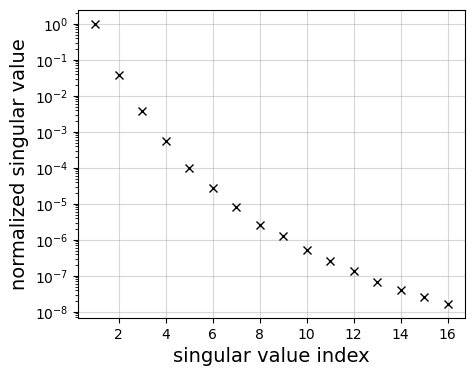

In [9]:
# opinf.basis.residual_energy(svdvals, 1e-8)
fig, ax = plt.subplots(1,1, figsize=(5, 4))
fontsize = 14

ax.semilogy(np.arange(1, len(svdvals)+1), svdvals / svdvals[0], marker = "x", color = "k", linestyle = "None")

# ax.set_ylim(1e-6, 2)
ax.set_xlabel("singular value index", fontsize=fontsize)
ax.set_ylabel("normalized singular value", fontsize=fontsize)
ax.grid(True, alpha=0.5)

# fig.savefig("/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/singular-value-decay.png", bbox_inches = "tight")

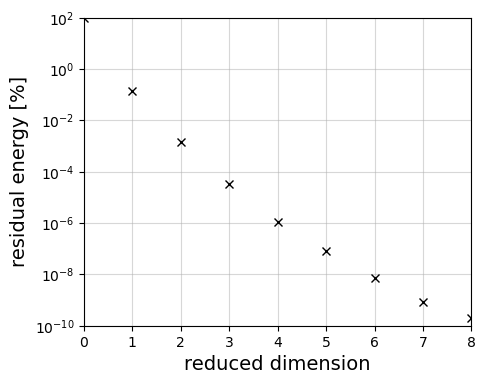

In [10]:
total_energy = np.sum(svdvals**2)
residual_energy = [100 * np.sum(svdvals[i:]**2) / total_energy for i in range(len(svdvals))]

# opinf.basis.residual_energy(svdvals, 1e-8)
fig, ax = plt.subplots(1,1, figsize=(5, 4))
fontsize = 14

ax.semilogy(np.arange(0, len(svdvals)), residual_energy, marker = "x", color = "k", linestyle = "None")

ax.set_ylim(1e-10, 100)
ax.set_xlim(0, 8)
ax.set_xlabel("reduced dimension", fontsize=fontsize)
ax.set_ylabel("residual energy [%]", fontsize=fontsize)
ax.grid(True, alpha=0.5)

# fig.savefig("/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/residual_energy.png", bbox_inches = "tight")

Both plots together

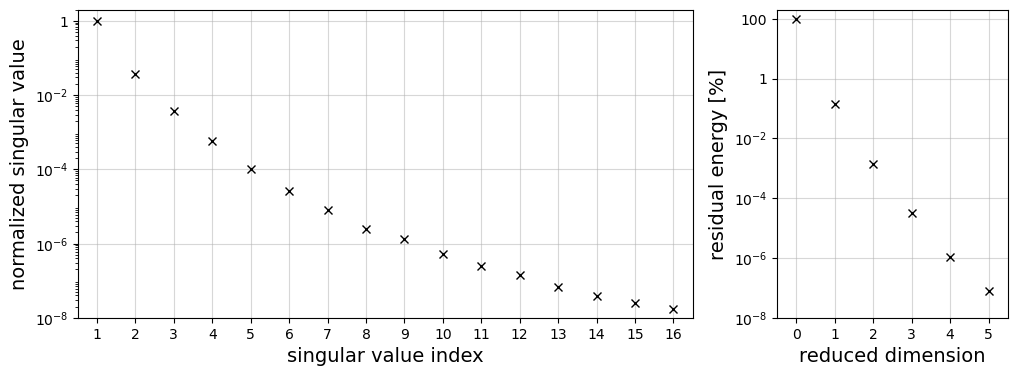

In [11]:
fig, axs = plt.subplots(1,2, figsize=(12, 4), width_ratios=[16, 6])
fontsize = 14

axs[0].semilogy(np.arange(1, len(svdvals)+1), svdvals / svdvals[0], marker = "x", color = "k", linestyle = "None")
axs[1].semilogy(np.arange(0, len(svdvals)), residual_energy, marker = "x", color = "k", linestyle = "None")

# ax.set_ylim(1e-6, 2)
axs[0].set_xlabel("singular value index", fontsize=fontsize)
axs[0].set_ylabel("normalized singular value", fontsize=fontsize)
axs[0].grid(True, alpha=0.5)
axs[0].set_xlim(0.5, 16.5)
axs[0].set_ylim(1e-8, 2)
axs[0].set_yticks([1e-8, 1e-6, 1e-4, 1e-2, 1], ["$10^{-8}$", "$10^{-6}$", "$10^{-4}$", "$10^{-2}$", 1])
axs[0].set_xticks(np.arange(1, 17), np.arange(1, 17))

axs[1].set_ylim(1e-8, 200)
axs[1].set_xlim(-0.5, 5.5)
axs[1].set_xlabel("reduced dimension", fontsize=fontsize)
axs[1].set_ylabel("residual energy [%]", fontsize=fontsize)
axs[1].grid(True, alpha=0.5)
axs[1].set_yticks([1e-8, 1e-6, 1e-4, 1e-2, 1, 100], ["$10^{-8}$", "$10^{-6}$", "$10^{-4}$", "$10^{-2}$", 1, 100])
axs[1].set_xticks([0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5])

#fig.savefig("/storage/nicole/git-save-data/opinf/cubic-heat/paper/plots/svals_and_residual_energy_2.png", bbox_inches = "tight")

Based on this plot, let's choose $r=5$, just to make things not too easy. We also apply Gram Schmidt, just to be sure the reduced space is still orthonormal after it was scaled back with the snapshots. We should really make this a part of the package though.

In [12]:
nRB = 5
VR = VR[:, :nRB]

# Gram Schmidt (just in case)
counter = 0
while (not np.isclose(VR.T @ fom.M @ VR, np.eye(nRB)).all()) and counter < 5:
    VR_old = VR.copy()
    for i in range(nRB):
        v_i = VR_old[:, i]
        for j in range(i):
            v_i = v_i - (v_i.T @ fom.M @ VR[:, j]) * VR[:, j]
        norm_vi = np.sqrt(v_i.T @ fom.M @ v_i)
        VR[:, i] = v_i / norm_vi
    counter += 1

What's the percentage of captured energy?

In [13]:
100 - residual_energy[nRB]

np.float64(99.9999999210776)

In [14]:
with open("/storage/nicole/git-save-data/opinf/cubic-heat/paper/training_test", "wb") as file:
        pickle.dump([Xi_train, U_train, VR, transformer, grid_t_train, U_para, final_training_time, fom.M], file)

## Intrusive ROM

We set up the intrusive ROM here just to have a first look at what we can at all expect from this reduced space.

In [15]:
ROMq = np.zeros(nRB, dtype = object)
for n in range(nRB):
    ROMq[n] = PolyRomIntrusiveTime(VR[:, :n+1], fom, transformer=transformer)
    ROMq[n].decompose()

We compute the error of the intrusive ROM and of the projection for different reduced space dimensions

In [16]:
# user input: choose which test parameter index to look at
i_test = 15

# initialization
U_test = U_para_test[i_test]
para_test = Xi_test[i_test, :]
names = ["intrusive", "projection"]
errors = np.zeros((len(names), nRB, grid_t.shape[0]))

for n in range(nRB):

    # intrusive
    i = 0
    sol_RB = ROMq[n].solve_ivp(grid_t = grid_t, para = para_test)
    Sol_RB = ROMq[n].toFO(sol_RB)
    errors[i, n, :] = fom.norm_over_time(Sol_RB - U_test, axis = 0)

    # projection
    i = 1
    if transformer is None:
        proj = VR[:, :n+1].T @ fom.M @ U_test
    else:
        proj = VR[:, :n+1].T @ fom.M @ transformer.transform(U_test)
    Proj = ROMq[n].toFO(proj) 
    errors[i, n, :] = fom.norm_over_time(Proj - U_test, axis = 0)

Time to plot the error

(-0.05, 1.05)

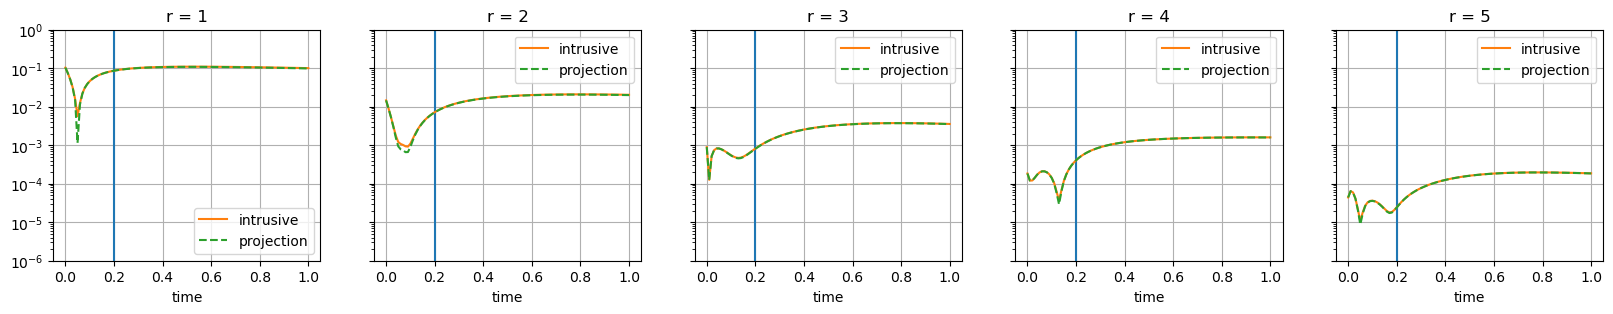

In [17]:
fig, axs = plt.subplots(1, nRB, sharey = True, sharex = True, figsize = (4*nRB, 3))

for j in range(nRB):
    axs[j].semilogy([final_training_time, final_training_time], [1e-12, 1e+12])

    axs[j].semilogy(grid_t[::10], errors[0, j, ::10], label = names[0])
    axs[j].semilogy(grid_t[::10], errors[1, j, ::10], label = names[1], linestyle = "--")

    axs[j].legend()
    axs[j].set_xlabel("time")
    axs[j].set_title("r = {}".format(j + 1))
    axs[j].grid(True)

axs[0].set_ylim((1e-6, 1e+0))
axs[0].set_xlim((0-0.05, 1 + 0.05))


## The End.

In [18]:
time_notebook = time.time() - tStart_notebook
print(f"Runtime of this notebook: {time_notebook / 60} min")

Runtime of this notebook: 0.22359441916147868 min
